In [1]:
from datetime import date, datetime
from urllib.parse import urljoin
from bs4 import BeautifulSoup
from pathlib import Path
from time import sleep
import subprocess
import requests
import pandas
import spacy
import glob
import time
import json
import csv
import re
import os

BASE_DIR = os.path.dirname(os.path.dirname(os.path.abspath("__file__")))  # go to ~/crossdem/ by jumping up twice
DATA_DIR = os.path.join(BASE_DIR, "datasets")
IMGS_DIR = os.path.join(os.getcwd(), "imgs")

os.makedirs(IMGS_DIR, exist_ok=True)

# TODO
Modify all so that they take N politicians

# Textual Analysis
Useful fields:
- politician
- historical_date
- location
- text

In [ ]:
POL_COLORS = {
    "degasperi":   "#2f4f4f",  # dark slate grey
    "fanfani":     "#e6194B",  # red
    "draghi":      "#3cb44b",  # green
    "meloni":      "#4363d8",  # blue
    "conte":       "#f58231",  # orange
    "gentiloni":   "#911eb4",  # purple
    "renzi":       "#42d4f4",  # cyan
    "letta":       "#f032e6",  # magenta
    "monti":       "#bfef45",  # lime
    "dini":        "#fabed4",  # pink
    "prodi":       "#469990",  # teal
    "d'alema":     "#dcbeff",  # lavender
    "ciampi":      "#9A6324",  # brown
    "berlusconi":  "#800000",  # dark red / maroon
    "amato":       "#aaffc3",  # mint
    #"de mita":     "#808000",  # olive
    #"craxi":       "#ffd8b1",  # apricot
    #"goria":       "#000075",  # navy
    #"spadolini":   "#a9a9a9",  # grey
    #"forlani":     "#ffe119",  # yellow
    #"cossiga":     "#e6beff",  # light violet
    #"rumor":       "#7f0067",  # deep magenta/plum
    #"colombo":      "#008080",  # dark teal
    "andreotti":   "#c00000",  # bright crimson
    #"moro":        "#556b2f",  # dark olive green
    #"leone":       "#ff4500",  # orange-red
    #"segni":       "#1e90ff",  # dodger blue
    #"scelba":      "#8b4513",  # saddle brown
}

In [3]:

POL_LEANING = {
    "degasperi":    "C",
    "fanfani":      "CL",  # Leader of DC's left wing, opened to the PSI (Center-Left)
    "draghi":       "C",   # Technocrat leading a grand unity coalition (Center)
    "meloni":       "R",   # Right-wing / National-conservative
    "conte":        "CL",  # Counted as Center-Left (especially Conte II / Five Star alignment)
    "gentiloni":    "CL",  # Democratic Party (Left / Center-Left)
    "renzi":        "CL",  # Democratic Party / Italia Viva (Center-Left)
    "letta":        "L",   # Democratic Party (Left / Center-Left)
    "monti":        "CR",  # Technocrat supported by a grand coalition, later ran as Center-Right/Center
    "dini":         "CL",  # Technocrat supported heavily by the Center-Left olive tree coalition
    "prodi":        "CL",  # Leader of L'Ulivo / L'Unione (Left / Center-Left)
    "d'alema":      "L",   # Democratic Party of the Left (Left)
    "ciampi":       "C",   # Institutional technocrat / independent (Center)
    "berlusconi":   "R",   # Forza Italia / Right-wing coalition
    "amato":        "L",   # PSI / Center-Left coalitions
    "de mita":      "CL",  # DC left wing (Center-Left coalition)
    "craxi":        "CL",  # PSI leader, led Pentapartito coalitions (Center-Left)
    "goria":        "C",   # DC centrist technocratic figure
    "spadolini":    "C",   # Republican Party (PRI), secular center
    "forlani":      "CR",  # DC right wing / Pentapartito era (Center-Right)
    "cossiga":      "CR",  # DC institutional center
    "rumor":        "C",   # DC centrist / led both Center and Center-Left coalitions
    "colombo":      "C",   # DC centrist (assuming "emilio" refers to Emilio Colombo)
    "andreotti":    "CR",  # DC right wing, leader of the conservative faction
    "moro":         "CL",  # Architect of the "compromesso storico" and opening to the Left
    "leone":        "C",   # DC institutional center
    "segni":        "CR",  # DC conservative wing
    "scelba":       "CR",  # DC conservative / staunch anti-communist right
}

In [ ]:
# De Gasperi was not scraped, a dataset with all speeches was taken from https://github.com/StefanoMenini/De-Gasperi-s-Corpus/
degasperi_df = pandas.read_csv(f"{DATA_DIR}/degasperi/degasperi_speeches.csv")

POLITICIANS = [
    "fanfani",
    "draghi",
    "meloni",
    "conte",
    "gentiloni",
    "renzi",
    "letta",
    "monti",
    "dini",
    "prodi",
    "d'alema",
    "ciampi",
    "berlusconi",
    "amato",
    #"de mita",
    #"craxi",
    #"goria",
    #"spadolini",
    #"forlani",
    #"cossiga",
    #"rumor",
    #"colombo",
    "andreotti",
    #"moro",
    #"leone",
    #"segni",
    #"scelba",
]

politicians_dfs = {
    "degasperi": degasperi_df
}

#for pol in politicians:
#    speeches = glob.glob(f"{DATA_DIR}/{pol}/csv_out/*.csv")
#    pol_df = pandas.concat([pandas.read_csv(f, nrows=1) for f in speeches], ignore_index=True)
#    politicians_dfs[pol] = pol_df


# csv faster for smaller datasets (eg 1 row)
def read_single_row(path):
    with open(path, newline="", encoding="utf-8") as f:
        return next(csv.DictReader(f))

for pol in POLITICIANS:
    speeches = glob.glob(f"{DATA_DIR}/{pol}/csv_out/*.csv")
    rows = [read_single_row(f) for f in speeches]
    politicians_dfs[pol] = pandas.DataFrame(rows)


#all_melonis = glob.glob(f"{DATA_DIR}/meloni/csv_out/*.csv")
#meloni_df =  pandas.concat([pandas.read_csv(f, nrows=1) for f in all_melonis], ignore_index=True)
#
#degasperi_df = pandas.read_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_speeches.csv")
#
##meloni_df.head()
##print(all_melonis)
#
#politicians_dfs = {
#    "meloni": meloni_df,
#    "degasperi": degasperi_df
#}

#print(politicians_dfs["conte"])
politicians_dfs["conte"].head()

,politician,historical_date,location,title,url,audio_file,text
0,conte,2003-02-13,UNKNOWN,La proposta avanzata da Marco Pannella di conc...,https://www.radioradicale.it/scheda/144567/la-...,crossdem/datasets/conte/audio_out/144567_conte...,e anche con il taglio di certe manifestazioni ...
1,conte,2002-08-04,CAPALBIO,"""Altri hotel"" ""Il terzo ufficiale"" ""Il soffio ...",https://www.radioradicale.it/scheda/144720/alt...,crossdem/datasets/conte/audio_out/144720_conte...,l'esperienza dei suoi viaggi in particolare de...
2,conte,2004-06-05,UNKNOWN,Un bilancio della visita di Marco Pannella e d...,https://www.radioradicale.it/scheda/156269/un-...,crossdem/datasets/conte/audio_out/156269_conte...,Sottotitoli creati dalla comunità Amara.org So...
3,conte,2004-06-29,LATRONICO,"""Diritti civili e umani in Italia e nel mondo....",https://www.radioradicale.it/scheda/157348/dir...,crossdem/datasets/conte/audio_out/157348_conte...,su questo tema e quindi è questo anche oltre c...
4,conte,2006-07-01,UNKNOWN,Serata per Enzo Siciliano,https://www.radioradicale.it/scheda/200864/ser...,crossdem/datasets/conte/audio_out/200864_conte...,"che ne andava a mani vuote, non mi sembra il c..."


In [5]:

# --- Helper function ---
def speech_stats(df, name):
    # Date range
    dates = pandas.to_datetime(df["historical_date"], format="%Y-%m-%d", errors="coerce")    
    oldest = dates.min()
    newest = dates.max()

    # Median word count
    word_counts = df["text"].dropna().str.split().str.len()
    median_wc = word_counts.median()

    print(f"=== {name} ===")
    print(f"  Date range : {oldest.date()} → {newest.date()}")
    print(f"  Speeches   : {len(df)}")
    print(f"  Median words/speech: {median_wc:.0f}")
    print()

#speech_stats(meloni_df, "Meloni")
#speech_stats(degasperi_df, "De Gasperi")

for pol, df in politicians_dfs.items():
    #print(pol)
    #print(df)
    speech_stats(df, pol)

=== degasperi ===
  Date range : 1901-09-21 → 1954-07-24
  Speeches   : 473
  Median words/speech: 701

=== fanfani ===
  Date range : 1962-03-22 → 1993-07-25
  Speeches   : 21
  Median words/speech: 774

=== draghi ===
  Date range : 1996-11-22 → 2015-12-14
  Speeches   : 22
  Median words/speech: 3558

=== meloni ===
  Date range : 2000-10-16 → 2026-05-21
  Speeches   : 193
  Median words/speech: 1225

=== conte ===
  Date range : 2002-08-04 → 2025-06-21
  Speeches   : 26
  Median words/speech: 594

=== gentiloni ===
  Date range : 2023-06-28 → 2023-06-28
  Speeches   : 1
  Median words/speech: 566

=== renzi ===
  Date range : 1997-06-13 → 2024-05-11
  Speeches   : 125
  Median words/speech: 1425

=== letta ===
  Date range : 1992-09-06 → 2021-11-23
  Speeches   : 451
  Median words/speech: 2115

=== monti ===
  Date range : 1991-10-04 → 2017-03-14
  Speeches   : 206
  Median words/speech: 2076

=== dini ===
  Date range : 1989-02-21 → 2023-06-01
  Speeches   : 290
  Median words/sp


## Number of tokens per PM
> Measures the amount of collected data


In [6]:
import spacy

# Load Italian model if your speeches are in Italian, otherwise use en_core_web_sm
# pip install spacy && python3 -m spacy download it_core_news_sm
nlp = spacy.load("it_core_news_sm")


In [7]:

# Disable unneeded pipeline components for speed — we only need tokenization
nlp.select_pipes(enable=[])  # disables everything except tokenizer

def count_tokens(text):
    if pandas.isna(text) or not isinstance(text, str):
        return 0
    return len(nlp(text))

summaries = []
for pol, df in politicians_dfs.items():
    speech_stats(df, pol)
    df["token_count"] = df["text"].apply(count_tokens)
    summary = (
        df.assign(politician=pol)
        .groupby("politician")["token_count"]
        .agg(total_tokens="sum", speech_count="count", avg_tokens_per_speech="mean")
        .reset_index()
    )
    summaries.append(summary)

token_summary = pandas.concat(summaries, ignore_index=True)
print(token_summary)

print(f"\nTotal tokens across all politicians: {token_summary['total_tokens'].sum()}")
print(f"Total speeches across all politicians: {token_summary['speech_count'].sum()}")

=== degasperi ===
  Date range : 1901-09-21 → 1954-07-24
  Speeches   : 473
  Median words/speech: 701

=== fanfani ===
  Date range : 1962-03-22 → 1993-07-25
  Speeches   : 21
  Median words/speech: 774

=== draghi ===
  Date range : 1996-11-22 → 2015-12-14
  Speeches   : 22
  Median words/speech: 3558

=== meloni ===
  Date range : 2000-10-16 → 2026-05-21
  Speeches   : 193
  Median words/speech: 1225

=== conte ===
  Date range : 2002-08-04 → 2025-06-21
  Speeches   : 26
  Median words/speech: 594

=== gentiloni ===
  Date range : 2023-06-28 → 2023-06-28
  Speeches   : 1
  Median words/speech: 566

=== renzi ===
  Date range : 1997-06-13 → 2024-05-11
  Speeches   : 125
  Median words/speech: 1425

=== letta ===
  Date range : 1992-09-06 → 2021-11-23
  Speeches   : 451
  Median words/speech: 2115

=== monti ===
  Date range : 1991-10-04 → 2017-03-14
  Speeches   : 206
  Median words/speech: 2076

=== dini ===
  Date range : 1989-02-21 → 2023-06-01
  Speeches   : 290
  Median words/sp


## MTLD Measure of Textual Lexical Diversity
> Measures lexical diversity

By sequentially evaluating the Type-Token Ratio (TTR) across segments, MTLD avoids the common problem of shorter texts artificially inflating lexical diversity 


In [8]:
from lexicalrichness import LexicalRichness

def compute_mtld(text):
    lex = LexicalRichness(text)
    # Need at least a few tokens for a meaningful MTLD
    if lex.words < 10:
        return None
    return lex.mtld(threshold=0.72)


summaries = []
for pol, df in politicians_dfs.items():
    #speech_stats(df, pol)
    df["mtld"] = df["text"].apply(compute_mtld)
    summary = (
        df.assign(politician=pol)
        .groupby("politician")["mtld"]
        .agg(
            avg_mtld="mean",
            median_mtld="median",
            speech_count="count"
        )
        .reset_index()
    )
    summaries.append(summary)


token_summary = pandas.concat(summaries, ignore_index=True)
print(token_summary)

    politician    avg_mtld  median_mtld  speech_count
0    degasperi  141.829723   137.642465           473
1      fanfani  111.910603   119.225097            21
2       draghi  133.022321   139.506869            22
3       meloni   96.348106    94.522959           193
4        conte  102.257658   109.965971            26
5    gentiloni  110.918686   110.918686             1
6        renzi   93.481653    91.647272           125
7        letta   84.952493    83.825802           451
8        monti  114.844521   116.901927           206
9         dini  108.589806   105.720272           290
10       prodi   93.375694    94.943184           446
11     d'alema   94.476626    93.737716           651
12      ciampi  114.018930   106.705292            57
13  berlusconi   91.008997    92.281991           438
14   andreotti  111.683991   109.552487            17


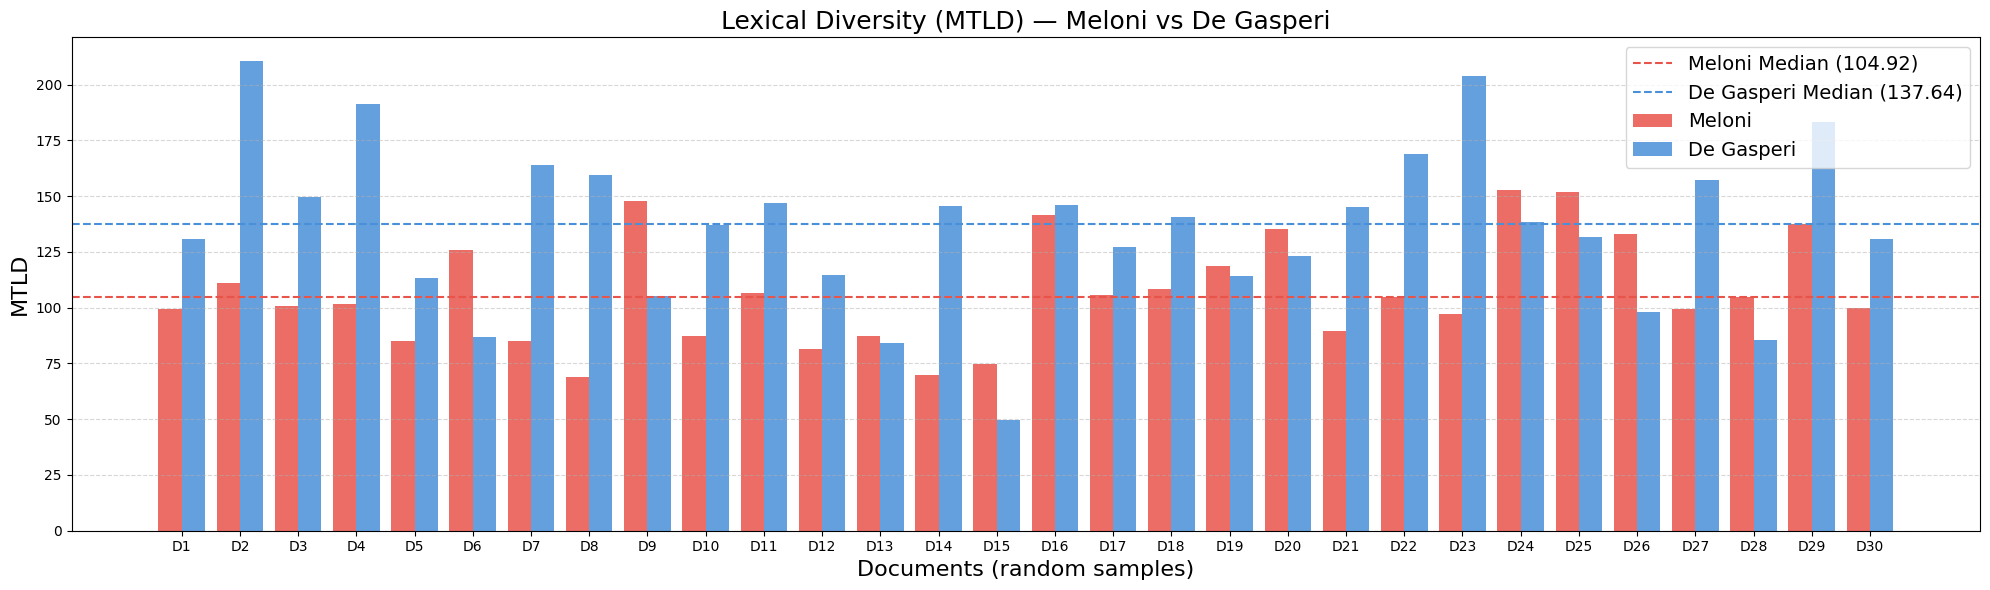

In [ ]:
    
if False:
    
    DOC_NUM = 30
    
    meloni_plot = meloni_df["mtld"].dropna().sample(n=DOC_NUM, random_state=42).reset_index(drop=True)
    degasperi_plot = degasperi_df["mtld"].dropna().sample(n=DOC_NUM, random_state=42).reset_index(drop=True)
    
    meloni_med = meloni_df["mtld"].dropna().median()
    degasperi_med = degasperi_df["mtld"].dropna().median()
    
    x = np.arange(DOC_NUM)
    width = 0.4
    
    fig, ax = plt.subplots(figsize=(20, 6))
    
    ax.bar(x - width/2, meloni_plot, width, label="Meloni", color="#E8534A", alpha=0.85)
    ax.bar(x + width/2, degasperi_plot, width, label="De Gasperi", color="#4A90D9", alpha=0.85)
    
    ax.axhline(meloni_med, color="#E8534A", linestyle="--", linewidth=1.5, label=f"Meloni Median ({meloni_med:.2f})")
    ax.axhline(degasperi_med, color="#4A90D9", linestyle="--", linewidth=1.5, label=f"De Gasperi Median ({degasperi_med:.2f})")
    
    ax.set_xlabel("Documents (random samples)", fontsize=16)
    ax.set_ylabel("MTLD", fontsize=16)
    ax.set_title("Lexical Diversity (MTLD) — Meloni vs De Gasperi", fontsize=18)
    ax.set_xticks(x)
    ax.set_xticklabels([f"D{i+1}" for i in x], rotation=0, fontsize=10)
    ax.legend(fontsize=14, loc="upper right")
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.savefig("mtld_comparison.png", dpi=300)
    plt.show()

### Plotly Dynamically Choosing Politicians

In [ ]:
import plotly.graph_objects as go
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display
import numpy as np

PALETTE = px.colors.qualitative.Dark24
MAX_DOC_NUM = 50

def plot_mtld_bar(selected_pols, doc_num, show_medians):
    if not selected_pols:
        print("Select at least one politician.")
        return
    fig = go.Figure()
    n = len(selected_pols)
    width = 0.8 / n
    x = np.arange(doc_num)
    for i, pol in enumerate(selected_pols):
        df = politicians_dfs[pol]
        name = pol.capitalize()
        vals = df["mtld"].dropna()
        sample_n = min(doc_num, len(vals))
        sample = vals.sample(n=sample_n, random_state=42).reset_index(drop=True)
        med = vals.median()
        #color = PALETTE[i % len(PALETTE)]
        color = POL_COLORS[pol]
        offset = (i - (n - 1) / 2) * width
        fig.add_bar(
            x=x[:sample_n] + offset,
            y=sample,
            width=width,
            name=name,
            marker_color=color,
            opacity=0.85,
            legendgroup=pol,
        )
        if show_medians:
            fig.add_hline(y=med, line_dash="dash", line_color=color)
            fig.add_scatter(
                x=[None], y=[None],
                mode="lines",
                line=dict(color=color, dash="dash"),
                name=f"Median ({med:.2f})",
                legendgroup=pol,
                showlegend=True,
            )
    fig.update_layout(
        xaxis_title="Documents (random samples)",
        yaxis_title="MTLD",
        barmode="group",
        template="plotly_white",
        autosize=True,
        height=600,
        margin=dict(t=20),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    fig.update_xaxes(
        tickmode="array",
        tickvals=x,
        ticktext=[f"D{i+1}" for i in x],
    )
    fig.show()

def plot_mtld_line(selected_pols, doc_num, show_medians):
    if not selected_pols:
        print("Select at least one politician.")
        return
    fig = go.Figure()
    for i, pol in enumerate(selected_pols):
        df = politicians_dfs[pol]
        name = pol.capitalize()
        vals = df["mtld"].dropna()
        sample_n = min(doc_num, len(vals))
        sample = vals.sample(n=sample_n, random_state=42).reset_index(drop=True)
        med = vals.median()
        #color = PALETTE[i % len(PALETTE)]
        color = POL_COLORS[pol]
        x = np.arange(sample_n)
        fig.add_scatter(
            x=x,
            y=sample,
            mode="lines+markers",
            name=name,
            line=dict(color=color, width=2.5),
            marker=dict(color=color, size=6),
            legendgroup=pol,
        )
        if show_medians:
            fig.add_hline(y=med, line_dash="dash", line_color=color)
            fig.add_scatter(
                x=[None], y=[None],
                mode="lines",
                line=dict(color=color, dash="dash"),
                name=f"Median ({med:.2f})",
                legendgroup=pol,
                showlegend=True,
            )
    fig.update_layout(
        xaxis_title="Documents (random samples)",
        yaxis_title="MTLD",
        template="plotly_white",
        autosize=True,
        height=600,
        margin=dict(t=20),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    fig.update_xaxes(
        tickmode="array",
        tickvals=np.arange(doc_num),
        ticktext=[f"D{i+1}" for i in range(doc_num)],
    )
    fig.show()

def plot_mtld(selected_pols, doc_num, view, show_medians):
    if view == "Bar":
        plot_mtld_bar(selected_pols, doc_num, show_medians)
    else:
        plot_mtld_line(selected_pols, doc_num, show_medians)
# --- checkbox grid (3 columns) ---
pol_names = list(politicians_dfs.keys())
checkboxes = []
for pol in pol_names:
    cb = widgets.Checkbox(
        value=(pol in ["meloni", "degasperi"]),
        description=pol.capitalize(),
        indent=False,
        layout=widgets.Layout(width="180px"),
    )
    cb.pol_key = pol
    checkboxes.append(cb)

# --- "All" checkbox ---
all_checkbox = widgets.Checkbox(
    value=False,
    description="All",
    indent=False,
    layout=widgets.Layout(width="180px"),
)

_syncing = False  # guard flag to prevent observer feedback loops

def on_all_change(change):
    global _syncing
    if _syncing:
        return
    _syncing = True
    for cb in checkboxes:
        cb.value = change["new"]
    _syncing = False
    redraw()

def on_individual_change(change):
    global _syncing
    if _syncing:
        return
    _syncing = True
    all_checkbox.value = all(cb.value for cb in checkboxes)
    _syncing = False
    redraw()

all_checkbox.observe(on_all_change, names="value")
for cb in checkboxes:
    cb.observe(on_individual_change, names="value")

checkbox_grid = widgets.GridBox(
    [all_checkbox] + checkboxes,
    layout=widgets.Layout(
        width="100%",
        grid_template_columns="repeat(auto-fill, minmax(150px, 1fr))",
    )
)

doc_slider = widgets.IntSlider(
    value=30, min=1, max=MAX_DOC_NUM, step=1,
    description="Docs:",
    continuous_update=False,
)

view_toggle = widgets.ToggleButtons(
    options=["Bar", "Line"],
    value="Bar",
    description="View:",
)

median_toggle = widgets.Checkbox(
    value=True,
    description="Show medians",
    indent=False,
)

title_label = widgets.HTML()

def _title_html(view):
    return (
        f"<h2 style='margin: 12px 0 4px 0; font-family: sans-serif; text-align: center;'>"
        f"Lexical Diversity (MTLD) Comparison — {view}</h2>"
    )

title_label.value = _title_html(view_toggle.value)

output = widgets.Output()

def redraw(change=None):
    selected = [cb.pol_key for cb in checkboxes if cb.value]
    title_label.value = _title_html(view_toggle.value)
    with output:
        output.clear_output(wait=True)
        plot_mtld(selected, doc_slider.value, view_toggle.value, median_toggle.value)

doc_slider.observe(redraw, names="value")
view_toggle.observe(redraw, names="value")
median_toggle.observe(redraw, names="value")

display(checkbox_grid, doc_slider, view_toggle, median_toggle, title_label, output)
redraw()  # initial draw

GridBox(children=(Checkbox(value=False, description='All', indent=False, layout=Layout(width='180px')), Checkb…

IntSlider(value=30, continuous_update=False, description='Docs:', max=50, min=1)

ToggleButtons(description='View:', options=('Bar', 'Line'), value='Bar')

Checkbox(value=True, description='Show medians', indent=False)

HTML(value="<h2 style='margin: 12px 0 4px 0; font-family: sans-serif; text-align: center;'>Lexical Diversity (…

Output()

#### Export In GitHub Pages


In [ ]:
"""
Run this once inside your notebook (where `politicians_dfs` and `POL_COLORS`
already exist) to produce data.json for the GitHub Pages site.

Usage (in a notebook cell):
    exec(open("export_data.py").read())

Or just paste the body below directly into a cell.
"""

import json
from pathlib import Path


OUT_DIR = os.path.join(BASE_DIR, "docs")
os.makedirs(OUT_DIR, exist_ok=True)
OUT_PATH = Path(f"{OUT_DIR}/data.json")

data = {}
for pol, df in politicians_dfs.items():
    vals = df["mtld"].dropna().tolist()
    data[pol] = {
        "mtld": vals,
        "color": POL_COLORS[pol],
    }

with OUT_PATH.open("w", encoding="utf-8") as f:
    json.dump(data, f)

print(f"Wrote {OUT_PATH.resolve()} with {len(data)} politicians")


Wrote /home/mhetac/Documents/GitHub/crossdem/interactive_visual/data.json with 13 politicians


### VDEM MTLD

In [9]:
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

YEAR_MIN, YEAR_MAX = 1945, 2025

# --- build one long dataframe: pol, year, mtld, leaning ---
def build_year_df():
    frames = []
    for pol, df in politicians_dfs.items():
        d = df[["historical_date", "mtld"]].dropna().copy()
        d["year"] = pd.to_datetime(d["historical_date"], errors="coerce").dt.year
        d["pol"] = pol
        d["leaning"] = POL_LEANING.get(pol)
        frames.append(d)
    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=["year"])
    out["year"] = out["year"].astype(int)
    return out

all_speeches_df = build_year_df()

GROUPS = {
    "Combined":            None,
    "Left (CL/L)":    ("CL", "L"),
    "Right (CR/R)":   ("CR", "R"),
    "Center (C)":     ("C",),
}

GROUP_COLORS = {
    "Combined":          "#7f7f7f",
    "Left (CL/L)":  "#d62728",
    "Right (CR/R)": "#1f77b4",
    "Center (C)":   "#2ca02c",
}

#----- agnostic on speeches amount and gaussian smoothing ------
def compute_series(leanings, stat, mode, smooth_window):
    d = all_speeches_df
    if leanings is not None:
        d = d[d["leaning"].isin(leanings)]
    agg_func = "median" if stat == "Median" else "mean"

    # step 1: collapse to one value per politician per year (removes speech-count weighting)
    pol_year = d.groupby(["year", "pol"])["mtld"].agg(agg_func)

    # step 2: aggregate across politicians, each counted once regardless of speech volume
    s = pol_year.groupby("year").agg(agg_func)

    full_years = pd.RangeIndex(YEAR_MIN, YEAR_MAX + 1)
    s = s.reindex(full_years)

    if mode == "Smoothed" and smooth_window > 1:
        s = s.rolling(window=smooth_window, center=True, min_periods=1, win_type="gaussian").mean(std=smooth_window / 3)
    return s

def plot_year_trends(selected_groups, stat, mode, smooth_window, chart_type):
    if not selected_groups:
        print("Select at least one group.")
        return
    fig = go.Figure()
    for g in selected_groups:
        s = compute_series(GROUPS[g], stat, mode, smooth_window)

        if chart_type == "Bar":
            fig.add_bar(
                x=s.index,
                y=s.values,
                name=g,
                marker=dict(color=GROUP_COLORS[g]),
            )
        else:
            line_kwargs = dict(color=GROUP_COLORS[g], width=2.5)
            marker_kwargs = dict(color=GROUP_COLORS[g], size=5)
            if mode == "Smoothed":
                line_kwargs["shape"] = "spline"
                plot_mode = "lines"
            else:
                plot_mode = "lines+markers"
            fig.add_scatter(
                x=s.index,
                y=s.values,
                mode=plot_mode,
                name=g,
                line=line_kwargs,
                marker=marker_kwargs,
                connectgaps=True,
            )

    subtitle = f"({mode}, window={smooth_window})" if mode == "Smoothed" else "(exact yearly values)"
    fig.update_layout(
        title=f"{stat} MTLD by Year and Political Leaning {subtitle}",
        xaxis_title="Year",
        yaxis_title=f"{stat} MTLD",
        xaxis=dict(range=[YEAR_MIN, YEAR_MAX], dtick=5),
        template="plotly_white",
        autosize=True,
        height=600,
        margin=dict(t=60),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        barmode="group",
    )
    fig.show()

# --- widgets ---
group_checkboxes = []
for g in GROUPS:
    cb = widgets.Checkbox(value=(g == "Combined"), description=g, indent=False,
                           layout=widgets.Layout(width="180px"))
    cb.group_key = g
    group_checkboxes.append(cb)

group_grid = widgets.GridBox(
    group_checkboxes,
    layout=widgets.Layout(width="100%", grid_template_columns="repeat(auto-fill, minmax(160px, 1fr))"),
)

stat_toggle = widgets.ToggleButtons(
    options=["Median", "Average"],
    value="Median",
    description="Stat:",
)

mode_toggle = widgets.ToggleButtons(
    options=["Exact", "Smoothed"],
    value="Exact",
    description="Mode:",
)

chart_type_toggle = widgets.ToggleButtons(
    options=["Line", "Bar"],
    value="Line",
    description="Chart:",
)

smooth_slider = widgets.IntSlider(
    value=5, min=1, max=15, step=1,
    description="Smoothing:",
    continuous_update=False,
    disabled=True,
)

output = widgets.Output()
def on_mode_change(change):
    smooth_slider.disabled = (change["new"] != "Smoothed")
    redraw()

def on_chart_type_change(change):
    if change["new"] == "Bar":
        if mode_toggle.value == "Smoothed":
            mode_toggle.value = "Exact"  # triggers on_mode_change -> disables slider, redraws
        mode_toggle.disabled = True
    else:
        mode_toggle.disabled = False
    redraw()

output = widgets.Output()

def redraw(change=None):
    selected = [cb.group_key for cb in group_checkboxes if cb.value]
    with output:
        output.clear_output(wait=True)
        plot_year_trends(
            selected, stat_toggle.value, mode_toggle.value,
            smooth_slider.value, chart_type_toggle.value,
        )

for cb in group_checkboxes:
    cb.observe(redraw, names="value")
stat_toggle.observe(redraw, names="value")
mode_toggle.observe(on_mode_change, names="value")
chart_type_toggle.observe(on_chart_type_change, names="value")
smooth_slider.observe(redraw, names="value")

display(group_grid, stat_toggle, mode_toggle, chart_type_toggle, smooth_slider, output)
redraw()

GridBox(children=(Checkbox(value=True, description='Combined', indent=False, layout=Layout(width='180px')), Ch…

ToggleButtons(description='Stat:', options=('Median', 'Average'), value='Median')

ToggleButtons(description='Mode:', options=('Exact', 'Smoothed'), value='Exact')

ToggleButtons(description='Chart:', options=('Line', 'Bar'), value='Line')

IntSlider(value=5, continuous_update=False, description='Smoothing:', disabled=True, max=15, min=1)

Output()

In [11]:
vdem = pandas.read_csv(f"{DATA_DIR}/vdem/V-Dem-CY-Core-v16_csv/V-Dem-CY-Core-v16.csv") # not full df so ofcs no italy
italy = vdem[vdem["country_name"] == "Italy"]                               
#italy.head()
print(f"{italy["v2x_polyarchy"]}")

12702      NaN
12703    0.207
12704    0.207
12705    0.207
12706    0.205
         ...  
12862    0.857
12863    0.842
12864    0.806
12865    0.784
12866    0.745
Name: v2x_polyarchy, Length: 165, dtype: float64


#### VDem Needed Data
**CY Country Year:**
- year granularity
- 5 indices
- 93 sub-indices
- 179 indicators

Features:
- **Identifiers:**
  - `historical_date`
    - YYYY-MM-DD
    - $\in$ CY datasets but has no meaning
    - for election-date-specific variables
      - $\forall$ other variables $=1_st$ january
- **Democracy Indices:**
  - $1_st$ level indices
  - $\forall scale=[1,0]$ unless otherwise specified
  - `v2x_polyarchy`
    - *electoral* democracy index
  - `v2x_libdem`
    - *liberal* democracy index
  - `v2x_partipdem`
    - *participatory* democracy index
- **Components of Democracy Indices** 
  - $2_nd$ level indices
  - subcomponents of Democracy Indices
  - `v2xel_frefair`
    - elections quality
      - free
      - fair
  - `v2xcl_rol`
    - laws transparency
    - laws fair enforcement
    - individual rights and liberties
  - `v2xlg_legcon`
    - executive external scrutiny


In [ ]:

import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display

YEAR_MIN, YEAR_MAX = 1945, 2025

# --- build one long dataframe: pol, year, mtld, leaning ---
def build_year_df():
    frames = []
    for pol, df in politicians_dfs.items():
        d = df[["historical_date", "mtld"]].dropna().copy()
        d["year"] = pandas.to_datetime(d["historical_date"], errors="coerce").dt.year
        d["pol"] = pol
        d["leaning"] = POL_LEANING.get(pol)
        frames.append(d)
    out = pandas.concat(frames, ignore_index=True)
    out = out.dropna(subset=["year"])
    out["year"] = out["year"].astype(int)
    return out

all_speeches_df = build_year_df()

GROUPS = {
    "Combined":            None,
    "Left (CL/L)":    ("CL", "L"),
    "Right (CR/R)":   ("CR", "R"),
    "Center (C)":     ("C",),
}

GROUP_COLORS = {
    "Combined":          "#7f7f7f",
    "Left (CL/L)":  "#d62728",
    "Right (CR/R)": "#1f77b4",
    "Center (C)":   "#2ca02c",
}

# --- V-Dem: Italy, indices for overlay ---
VDEM_VARS = {
    "Electoral democracy (polyarchy)": "v2x_polyarchy",
    "Liberal democracy":               "v2x_libdem",
    "Participatory democracy":         "v2x_partipdem",
    "Election quality (free & fair)":  "v2xel_frefair",
    "Rule of law / civil liberties":   "v2xcl_rol",
    "Legislative constraints on exec.": "v2xlg_legcon",
}

VDEM_COLORS = {
    "Electoral democracy (polyarchy)": "#9467bd",
    "Liberal democracy":               "#8c564b",
    "Participatory democracy":         "#e377c2",
    "Election quality (free & fair)":  "#17becf",
    "Rule of law / civil liberties":   "#bcbd22",
    "Legislative constraints on exec.": "#ff7f0e",
}

vdem = pandas.read_csv(f"{DATA_DIR}/vdem/V-Dem-CY-Core-v16_csv/V-Dem-CY-Core-v16.csv") # not full df so ofcs no italy
italy_vdem = vdem[vdem["country_name"] == "Italy"][["year"] + list(VDEM_VARS.values())].copy()
italy_vdem = italy_vdem.set_index("year").sort_index()

def get_vdem_series(col):
    full_years = pandas.RangeIndex(YEAR_MIN, YEAR_MAX + 1)
    return italy_vdem[col].reindex(full_years)

#----- agnostic on speeches amount and gaussian smoothing ------
def compute_series(leanings, stat, mode, smooth_window):
    d = all_speeches_df
    if leanings is not None:
        d = d[d["leaning"].isin(leanings)]
    agg_func = "median" if stat == "Median" else "mean"

    pol_year = d.groupby(["year", "pol"])["mtld"].agg(agg_func)
    s = pol_year.groupby("year").agg(agg_func)

    full_years = pandas.RangeIndex(YEAR_MIN, YEAR_MAX + 1)
    s = s.reindex(full_years)

    if mode == "Smoothed" and smooth_window > 1:
        s = s.rolling(window=smooth_window, center=True, min_periods=1, win_type="gaussian").mean(std=smooth_window / 3)
    return s

def plot_year_trends(selected_groups, stat, mode, smooth_window, chart_type, selected_vdem):
    if not selected_groups and not selected_vdem:
        print("Select at least one group or V-Dem index.")
        return
    fig = go.Figure()

    for g in selected_groups:
        s = compute_series(GROUPS[g], stat, mode, smooth_window)

        if chart_type == "Bar":
            fig.add_bar(
                x=s.index,
                y=s.values,
                name=g,
                marker=dict(color=GROUP_COLORS[g]),
            )
        else:
            line_kwargs = dict(color=GROUP_COLORS[g], width=2.5)
            marker_kwargs = dict(color=GROUP_COLORS[g], size=5)
            if mode == "Smoothed":
                line_kwargs["shape"] = "spline"
                plot_mode = "lines"
            else:
                plot_mode = "lines+markers"
            fig.add_scatter(
                x=s.index,
                y=s.values,
                mode=plot_mode,
                name=g,
                line=line_kwargs,
                marker=marker_kwargs,
                connectgaps=True,
            )

    # V-Dem overlays: always a line, always on secondary axis, regardless of chart_type
    for v in selected_vdem:
        col = VDEM_VARS[v]
        s = get_vdem_series(col)
        fig.add_scatter(
            x=s.index,
            y=s.values,
            mode="lines",
            name=v,
            line=dict(color=VDEM_COLORS[v], width=2, dash="dot"),
            yaxis="y2",
            connectgaps=True,
        )

    subtitle = f"({mode}, window={smooth_window})" if mode == "Smoothed" else "(exact yearly values)"
    fig.update_layout(
        title=f"{stat} MTLD by Year and Political Leaning {subtitle}",
        xaxis_title="Year",
        yaxis_title=f"{stat} MTLD",
        xaxis=dict(range=[YEAR_MIN, YEAR_MAX], dtick=5),
        yaxis2=dict(
            title="V-Dem index (0–1)",
            overlaying="y",
            side="right",
            range=[0, 1],
            showgrid=False,
        ),
        template="plotly_white",
        autosize=True,
        height=600,
        margin=dict(t=60),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        barmode="group",
    )
    fig.show()

# --- widgets ---
group_checkboxes = []
for g in GROUPS:
    cb = widgets.Checkbox(value=(g == "Combined"), description=g, indent=False,
                           layout=widgets.Layout(width="180px"))
    cb.group_key = g
    group_checkboxes.append(cb)

group_grid = widgets.GridBox(
    group_checkboxes,
    layout=widgets.Layout(width="100%", grid_template_columns="repeat(auto-fill, minmax(160px, 1fr))"),
)

vdem_checkboxes = []
for v in VDEM_VARS:
    cb = widgets.Checkbox(value=False, description=v, indent=False,
                           layout=widgets.Layout(width="260px"))
    cb.var_key = v
    vdem_checkboxes.append(cb)

vdem_grid = widgets.GridBox(
    vdem_checkboxes,
    layout=widgets.Layout(width="100%", grid_template_columns="repeat(auto-fill, minmax(240px, 1fr))"),
)

stat_toggle = widgets.ToggleButtons(
    options=["Median", "Average"],
    value="Median",
    description="Stat:",
)

mode_toggle = widgets.ToggleButtons(
    options=["Exact", "Smoothed"],
    value="Exact",
    description="Mode:",
)

chart_type_toggle = widgets.ToggleButtons(
    options=["Line", "Bar"],
    value="Line",
    description="Chart:",
)

smooth_slider = widgets.IntSlider(
    value=5, min=1, max=15, step=1,
    description="Smoothing:",
    continuous_update=False,
    disabled=True,
)

output = widgets.Output()

def on_mode_change(change):
    smooth_slider.disabled = (change["new"] != "Smoothed")
    redraw()

def on_chart_type_change(change):
    if change["new"] == "Bar":
        if mode_toggle.value == "Smoothed":
            mode_toggle.value = "Exact"  # triggers on_mode_change -> disables slider, redraws
        mode_toggle.disabled = True
    else:
        mode_toggle.disabled = False
    redraw()

def redraw(change=None):
    selected = [cb.group_key for cb in group_checkboxes if cb.value]
    selected_vdem = [cb.var_key for cb in vdem_checkboxes if cb.value]
    with output:
        output.clear_output(wait=True)
        plot_year_trends(
            selected, stat_toggle.value, mode_toggle.value,
            smooth_slider.value, chart_type_toggle.value,
            selected_vdem,
        )

for cb in group_checkboxes:
    cb.observe(redraw, names="value")
for cb in vdem_checkboxes:
    cb.observe(redraw, names="value")
stat_toggle.observe(redraw, names="value")
mode_toggle.observe(on_mode_change, names="value")
chart_type_toggle.observe(on_chart_type_change, names="value")
smooth_slider.observe(redraw, names="value")

display(group_grid, widgets.HTML("<b>V-Dem indices (Italy):</b>"), vdem_grid,
        stat_toggle, mode_toggle, chart_type_toggle, smooth_slider, output)
redraw()

GridBox(children=(Checkbox(value=True, description='Combined', indent=False, layout=Layout(width='180px')), Ch…

HTML(value='<b>V-Dem indices (Italy):</b>')

GridBox(children=(Checkbox(value=False, description='Electoral democracy (polyarchy)', indent=False, layout=La…

ToggleButtons(description='Stat:', options=('Median', 'Average'), value='Median')

ToggleButtons(description='Mode:', options=('Exact', 'Smoothed'), value='Exact')

ToggleButtons(description='Chart:', options=('Line', 'Bar'), value='Line')

IntSlider(value=5, continuous_update=False, description='Smoothing:', disabled=True, max=15, min=1)

Output()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display
from scipy.interpolate import UnivariateSpline

YEAR_MIN, YEAR_MAX = 1945, 2025

# --- build one long dataframe: pol, year, mtld, leaning ---
def build_year_df():
    frames = []
    for pol, df in politicians_dfs.items():
        d = df[["historical_date", "mtld"]].dropna().copy()
        d["year"] = pd.to_datetime(d["historical_date"], errors="coerce").dt.year
        d["pol"] = pol
        d["leaning"] = POL_LEANING.get(pol)
        frames.append(d)
    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=["year"])
    out["year"] = out["year"].astype(int)
    return out

all_speeches_df = build_year_df()

GROUPS = {
    "Combined":            None,
    "Left (CL/L)":    ("CL", "L"),
    "Right (CR/R)":   ("CR", "R"),
    "Center (C)":     ("C",),
}

GROUP_COLORS = {
    "Combined":          "#7f7f7f",
    "Left (CL/L)":  "#d62728",
    "Right (CR/R)": "#1f77b4",
    "Center (C)":   "#2ca02c",
}

# --- V-Dem: Italy, indices for overlay ---
VDEM_VARS = {
    "Electoral democracy": "v2x_polyarchy",
    "Liberal democracy":               "v2x_libdem",
    "Participatory democracy":         "v2x_partipdem",
    "Elections quality":  "v2xel_frefair",
    "Fairness of law & individual liberties":   "v2xcl_rol",
    "Scrutiny of Executives": "v2xlg_legcon",
}

VDEM_COLORS = {
    "Electoral democracy": "#9467bd",
    "Liberal democracy":               "#8c564b",
    "Participatory democracy":         "#e377c2",
    "Elections quality":  "#17becf",
    "Fairness of law & individual liberties":   "#bcbd22",
    "Scrutiny of Executives": "#ff7f0e",
}

italy_vdem = vdem[vdem["country_name"] == "Italy"][["year"] + list(VDEM_VARS.values())].copy()
italy_vdem = italy_vdem.set_index("year").sort_index()

def get_vdem_series(col):
    full_years = pd.RangeIndex(YEAR_MIN, YEAR_MAX + 1)
    return italy_vdem[col].reindex(full_years)

#----- agnostic on speeches amount, aggregates to one value per year -----
def yearly_series(leanings, stat):
    d = all_speeches_df
    if leanings is not None:
        d = d[d["leaning"].isin(leanings)]
    agg_func = "median" if stat == "Median" else "mean"

    # step 1: collapse to one value per politician per year (removes speech-count weighting)
    pol_year = d.groupby(["year", "pol"])["mtld"].agg(agg_func)
    # step 2: aggregate across politicians, each counted once regardless of speech volume
    s = pol_year.groupby("year").agg(agg_func)

    full_years = pd.RangeIndex(YEAR_MIN, YEAR_MAX + 1)
    return s.reindex(full_years)

def compute_series(leanings, stat, mode, smooth_window, trend_s):
    s = yearly_series(leanings, stat)

    if mode == "Smoothed" and smooth_window > 1:
        s = s.rolling(window=smooth_window, center=True, min_periods=1, win_type="gaussian").mean(std=smooth_window / 3)

    elif mode == "Trend":
        valid = s.dropna()
        x = valid.index.values.astype(float)
        y = valid.values.astype(float)
        if len(x) < 4:
            # not enough points for a cubic spline; fall back to whatever order is possible
            k = max(1, len(x) - 1)
        else:
            k = 3
        if len(x) >= 2:
            spline = UnivariateSpline(x, y, k=k, s=trend_s, ext=3)
            full_x = s.index.values.astype(float)
            s = pd.Series(spline(full_x), index=s.index)
        # else: leave as-is (all-NaN), nothing to fit

    return s

def plot_year_trends(selected_groups, stat, mode, smooth_window, trend_s, chart_type, selected_vdem):
    if not selected_groups and not selected_vdem:
        print("Select at least one group or V-Dem index.")
        return
    fig = go.Figure()

    for g in selected_groups:
        s = compute_series(GROUPS[g], stat, mode, smooth_window, trend_s)

        if chart_type == "Bar":
            fig.add_bar(
                x=s.index,
                y=s.values,
                name=g,
                marker=dict(color=GROUP_COLORS[g]),
            )
        else:
            line_kwargs = dict(color=GROUP_COLORS[g], width=2.5)
            marker_kwargs = dict(color=GROUP_COLORS[g], size=5)
            if mode in ("Smoothed", "Trend"):
                line_kwargs["shape"] = "spline" if mode == "Smoothed" else "linear"
                plot_mode = "lines"
            else:
                plot_mode = "lines+markers"
            fig.add_scatter(
                x=s.index,
                y=s.values,
                mode=plot_mode,
                name=g,
                line=line_kwargs,
                marker=marker_kwargs,
                connectgaps=True,
            )

    # V-Dem overlays: always a line, always on secondary axis, regardless of chart_type
    for v in selected_vdem:
        col = VDEM_VARS[v]
        s = get_vdem_series(col)
        fig.add_scatter(
            x=s.index,
            y=s.values,
            mode="lines",
            name=v,
            line=dict(color=VDEM_COLORS[v], width=2, dash="dot"),
            yaxis="y2",
            connectgaps=True,
        )

    if mode == "Smoothed":
        subtitle = f"(Smoothed, window={smooth_window})"
    elif mode == "Trend":
        subtitle = f"(Spline trend, s={trend_s})"
    else:
        subtitle = "(exact yearly values)"

    fig.update_layout(
        #title=f"{stat} MTLD by Year and Political Leaning {subtitle}",
        xaxis_title="Year",
        yaxis_title=f"{stat} MTLD",
        xaxis=dict(range=[YEAR_MIN, YEAR_MAX], dtick=5),
        yaxis2=dict(
            title="V-Dem index (0–1)",
            overlaying="y",
            side="right",
            range=[0, 1],
            showgrid=False,
        ),
        template="plotly_white",
        autosize=True,
        height=600,
        margin=dict(t=60),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        barmode="group",
    )
    fig.show()

# --- widgets ---
group_checkboxes = []
for g in GROUPS:
    cb = widgets.Checkbox(value=(g == "Combined"), description=g, indent=False,
                           layout=widgets.Layout(width="180px"))
    cb.group_key = g
    group_checkboxes.append(cb)

group_grid = widgets.GridBox(
    group_checkboxes,
    layout=widgets.Layout(width="100%", grid_template_columns="repeat(auto-fill, minmax(160px, 1fr))"),
)

vdem_checkboxes = []
for v in VDEM_VARS:
    cb = widgets.Checkbox(value=False, description=v, indent=False,
                           layout=widgets.Layout(width="260px"))
    cb.var_key = v
    vdem_checkboxes.append(cb)

vdem_grid = widgets.GridBox(
    vdem_checkboxes,
    layout=widgets.Layout(width="100%", grid_template_columns="repeat(auto-fill, minmax(240px, 1fr))"),
)

stat_toggle = widgets.ToggleButtons(
    options=["Median", "Average"],
    value="Median",
    description="Stat:",
)

mode_toggle = widgets.ToggleButtons(
    options=["Exact", "Smoothed", "Trend"],
    value="Exact",
    description="Mode:",
)

chart_type_toggle = widgets.ToggleButtons(
    options=["Line", "Bar"],
    value="Line",
    description="Chart:",
)

smooth_slider = widgets.IntSlider(
    value=5, min=1, max=15, step=1,
    description="Smoothing:",
    continuous_update=False,
    disabled=True,
)

trend_slider = widgets.FloatSlider(
    value=8, min=0, max=50, step=0.5,
    description="Trend s:",
    continuous_update=False,
    disabled=True,
    tooltip="Spline smoothing factor: 0 = interpolate exactly through points, higher = smoother/flatter curve",
)

output = widgets.Output()

def on_mode_change(change):
    smooth_slider.disabled = (change["new"] != "Smoothed")
    trend_slider.disabled = (change["new"] != "Trend")
    redraw()

def on_chart_type_change(change):
    if change["new"] == "Bar":
        if mode_toggle.value != "Exact":
            mode_toggle.value = "Exact"  # triggers on_mode_change -> disables sliders, redraws
        mode_toggle.disabled = True
    else:
        mode_toggle.disabled = False
    redraw()

def redraw(change=None):
    selected = [cb.group_key for cb in group_checkboxes if cb.value]
    selected_vdem = [cb.var_key for cb in vdem_checkboxes if cb.value]
    with output:
        output.clear_output(wait=True)
        plot_year_trends(
            selected, stat_toggle.value, mode_toggle.value,
            smooth_slider.value, trend_slider.value,
            chart_type_toggle.value, selected_vdem,
        )

for cb in group_checkboxes:
    cb.observe(redraw, names="value")
for cb in vdem_checkboxes:
    cb.observe(redraw, names="value")
stat_toggle.observe(redraw, names="value")
mode_toggle.observe(on_mode_change, names="value")
chart_type_toggle.observe(on_chart_type_change, names="value")
smooth_slider.observe(redraw, names="value")
trend_slider.observe(redraw, names="value")

display(group_grid, widgets.HTML("<b>V-Dem indices (Italy):</b>"), vdem_grid,
        stat_toggle, mode_toggle, chart_type_toggle, smooth_slider, trend_slider, output)
redraw()

GridBox(children=(Checkbox(value=True, description='Combined', indent=False, layout=Layout(width='180px')), Ch…

HTML(value='<b>V-Dem indices (Italy):</b>')

GridBox(children=(Checkbox(value=False, description='Electoral democracy', indent=False, layout=Layout(width='…

ToggleButtons(description='Stat:', options=('Median', 'Average'), value='Median')

ToggleButtons(description='Mode:', options=('Exact', 'Smoothed', 'Trend'), value='Exact')

ToggleButtons(description='Chart:', options=('Line', 'Bar'), value='Line')

IntSlider(value=5, continuous_update=False, description='Smoothing:', disabled=True, max=15, min=1)

FloatSlider(value=8.0, continuous_update=False, description='Trend s:', disabled=True, max=50.0, step=0.5, too…

Output()

In [ ]:
"""
export_data.py

Run this in the SAME kernel/notebook as your existing MTLD dashboard code,
right after the cells that build `politicians_dfs`, `POL_LEANING` and load
`vdem`. It reuses your existing GROUPS / VDEM_VARS definitions and pre-computes
every value the static site could ever need (exact yearly series, every
Gaussian-smoothed window 1-15, and every spline-trend s value on a 0.5 grid),
so the HTML/JS side never has to reimplement pandas rolling() or
UnivariateSpline — it just looks values up.

Output: data.json next to index.html.
"""

import json
import numpy as np
import pandas as pd
from scipy.interpolate import UnivariateSpline

YEAR_MIN, YEAR_MAX = 1945, 2025
YEARS = list(range(YEAR_MIN, YEAR_MAX + 1))

GROUPS = {
    "Combined": None,
    "Left (CL/L)": ("CL", "L"),
    "Right (CR/R)": ("CR", "R"),
    "Center (C)": ("C",),
}

VDEM_VARS = {
    "Electoral democracy": "v2x_polyarchy",
    "Liberal democracy": "v2x_libdem",
    "Participatory democracy": "v2x_partipdem",
    "Elections quality": "v2xel_frefair",
    "Fairness of law & individual liberties": "v2xcl_rol",
    "Scrutiny of Executives": "v2xlg_legcon",
}

STATS = ["Median", "Average"]
SMOOTH_WINDOWS = list(range(1, 16))          # matches smooth_slider 1..15 step 1
TREND_S_VALUES = [round(x * 0.5, 1) for x in range(0, 101)]  # 0..50 step 0.5


# ---------- rebuild the long dataframe (same logic as the notebook) ----------
def build_year_df():
    frames = []
    for pol, df in politicians_dfs.items():
        d = df[["historical_date", "mtld"]].dropna().copy()
        d["year"] = pd.to_datetime(d["historical_date"], errors="coerce").dt.year
        d["pol"] = pol
        d["leaning"] = POL_LEANING.get(pol)
        frames.append(d)
    out = pd.concat(frames, ignore_index=True)
    out = out.dropna(subset=["year"])
    out["year"] = out["year"].astype(int)
    return out


all_speeches_df = build_year_df()


def yearly_series(leanings, stat):
    d = all_speeches_df
    if leanings is not None:
        d = d[d["leaning"].isin(leanings)]
    agg_func = "median" if stat == "Median" else "mean"

    pol_year = d.groupby(["year", "pol"])["mtld"].agg(agg_func)
    s = pol_year.groupby("year").agg(agg_func)

    full_years = pd.RangeIndex(YEAR_MIN, YEAR_MAX + 1)
    return s.reindex(full_years)


def smoothed(s, window):
    if window <= 1:
        return s
    return s.rolling(window=window, center=True, min_periods=1,
                      win_type="gaussian").mean(std=window / 3)


def trended(s, trend_s):
    valid = s.dropna()
    x = valid.index.values.astype(float)
    y = valid.values.astype(float)
    if len(x) < 2:
        return pd.Series(np.nan, index=s.index)
    k = 3 if len(x) >= 4 else max(1, len(x) - 1)
    spline = UnivariateSpline(x, y, k=k, s=trend_s, ext=3)
    full_x = s.index.values.astype(float)
    return pd.Series(spline(full_x), index=s.index)


def series_to_list(s):
    # NaN -> None so it round-trips through JSON as `null`
    return [None if pd.isna(v) else round(float(v), 4) for v in s.values]


# ---------------------------- assemble data.json ----------------------------
data = {
    "year_min": YEAR_MIN,
    "year_max": YEAR_MAX,
    "years": YEARS,
    "groups": list(GROUPS.keys()),
    "stats": STATS,
    "smooth_windows": SMOOTH_WINDOWS,
    "trend_s_values": TREND_S_VALUES,
    "vdem_vars": list(VDEM_VARS.keys()),
    "exact": {},
    "smoothed": {},
    "trend": {},
    "vdem": {},
}

for g, leanings in GROUPS.items():
    data["exact"][g] = {}
    data["smoothed"][g] = {}
    data["trend"][g] = {}
    for stat in STATS:
        base = yearly_series(leanings, stat)
        data["exact"][g][stat] = series_to_list(base)

        data["smoothed"][g][stat] = {
            str(w): series_to_list(smoothed(base, w)) for w in SMOOTH_WINDOWS
        }

        data["trend"][g][stat] = {
            str(s_val): series_to_list(trended(base, s_val)) for s_val in TREND_S_VALUES
        }
        print(f"done: {g} / {stat}")

italy_vdem = vdem[vdem["country_name"] == "Italy"][["year"] + list(VDEM_VARS.values())].copy()
italy_vdem = italy_vdem.set_index("year").sort_index()
full_years_idx = pd.RangeIndex(YEAR_MIN, YEAR_MAX + 1)

for label, col in VDEM_VARS.items():
    s = italy_vdem[col].reindex(full_years_idx)
    data["vdem"][label] = series_to_list(s)

with open("data.json", "w") as f:
    json.dump(data, f)

print("Wrote data.json")


## Vocabulary Differences
> What are words that are used by De Gasperi and not by Meloni? And vice-versa

> What are the words most commonly used by De Gasperi and what by Meloni? 


In [8]:
# --- Tokenize and collect words (lowercase, alpha only) ---
def tokenize(text):
    return [token.text.lower() for token in nlp(text) 
            if token.is_alpha 
            and not token.is_stop 
            and len(token)>3
            ]

degasperi_words = []
meloni_words = []

for text in degasperi_df["text"]:
    degasperi_words.extend(tokenize(text))

for text in meloni_df["text"]:
    meloni_words.extend(tokenize(text))


### Words used only by De Gasperi and words used only by Meloni

In [9]:
# --- Top 1000 most frequent words per politician ---
from collections import Counter
degasperi_freq = Counter(degasperi_words)
meloni_freq    = Counter(meloni_words)

top1000_degasperi = {word for word, _ in degasperi_freq.most_common(1000)}
top1000_meloni    = {word for word, _ in meloni_freq.most_common(1000)}

# --- How different are the two top-1000 sets? ---
overlap     = top1000_degasperi & top1000_meloni
union       = top1000_degasperi | top1000_meloni
jaccard     = len(overlap) / len(union)          # 0 = totally different, 1 = identical

print(f"\nTop-1000 overlap:     {len(overlap)} words in common")
print(f"Jaccard similarity:   {jaccard:.2%}")


Top-1000 overlap:     489 words in common
Jaccard similarity:   32.36%


In [10]:
# --- Words in BOTH top-1000s, sorted by combined frequency ---
common_top1000 =  top1000_meloni & top1000_degasperi
ROWS_TO_PRINT = 20

print(f"=== Highest frequency common words ({len(common_top1000)} words) ===")
for word in sorted(common_top1000, key=lambda w: degasperi_freq[w] + meloni_freq[w], reverse=True)[:ROWS_TO_PRINT]:
    print(f"  {word:<25} degasperi: {degasperi_freq[word]:>6}   meloni: {meloni_freq[word]:>6}   freq sum: {meloni_freq[word]+degasperi_freq[word]:>6}")

# --- In Meloni's top-1000 but NOT De Gasperi's, sorted by Meloni frequency ---
meloni_not_degasperi = {w for w in top1000_meloni if degasperi_freq[w] == 0}

print(f"\n=== Highest frequency words in Meloni, not in De Gasperi ({len(meloni_not_degasperi)} words) ===")
for word in sorted(meloni_not_degasperi, key=lambda w: meloni_freq[w], reverse=True)[:ROWS_TO_PRINT]:
    print(f"  {word:<25} meloni: {meloni_freq[word]:>6}   degasperi: {degasperi_freq[word]:>6}")

# --- In De Gasperi's top-1000 but NOT Meloni's, sorted by De Gasperi frequency ---
degasperi_not_meloni = {w for w in top1000_degasperi if meloni_freq[w] == 0}

print(f"\n=== Highest frequency words in De Gasperi, not in Meloni  ({len(degasperi_not_meloni)} words) ===")
for word in sorted(degasperi_not_meloni, key=lambda w: degasperi_freq[w], reverse=True)[:ROWS_TO_PRINT]:
    print(f"  {word:<25} degasperi: {degasperi_freq[word]:>6}   meloni: {meloni_freq[word]:>6}")

=== Highest frequency common words (489 words) ===
  italia                    degasperi:   1544   meloni:    423   freq sum:   1967
  popolo                    degasperi:   1155   meloni:     46   freq sum:   1201
  libertà                   degasperi:    980   meloni:     91   freq sum:   1071
  guerra                    degasperi:    869   meloni:     58   freq sum:    927
  politica                  degasperi:    783   meloni:    129   freq sum:    912
  pace                      degasperi:    841   meloni:     69   freq sum:    910
  italiano                  degasperi:    758   meloni:     70   freq sum:    828
  presidente                degasperi:    509   meloni:    224   freq sum:    733
  democrazia                degasperi:    679   meloni:     29   freq sum:    708
  partito                   degasperi:    669   meloni:     13   freq sum:    682
  bisogna                   degasperi:    587   meloni:     74   freq sum:    661
  italiani                  degasperi:    531  

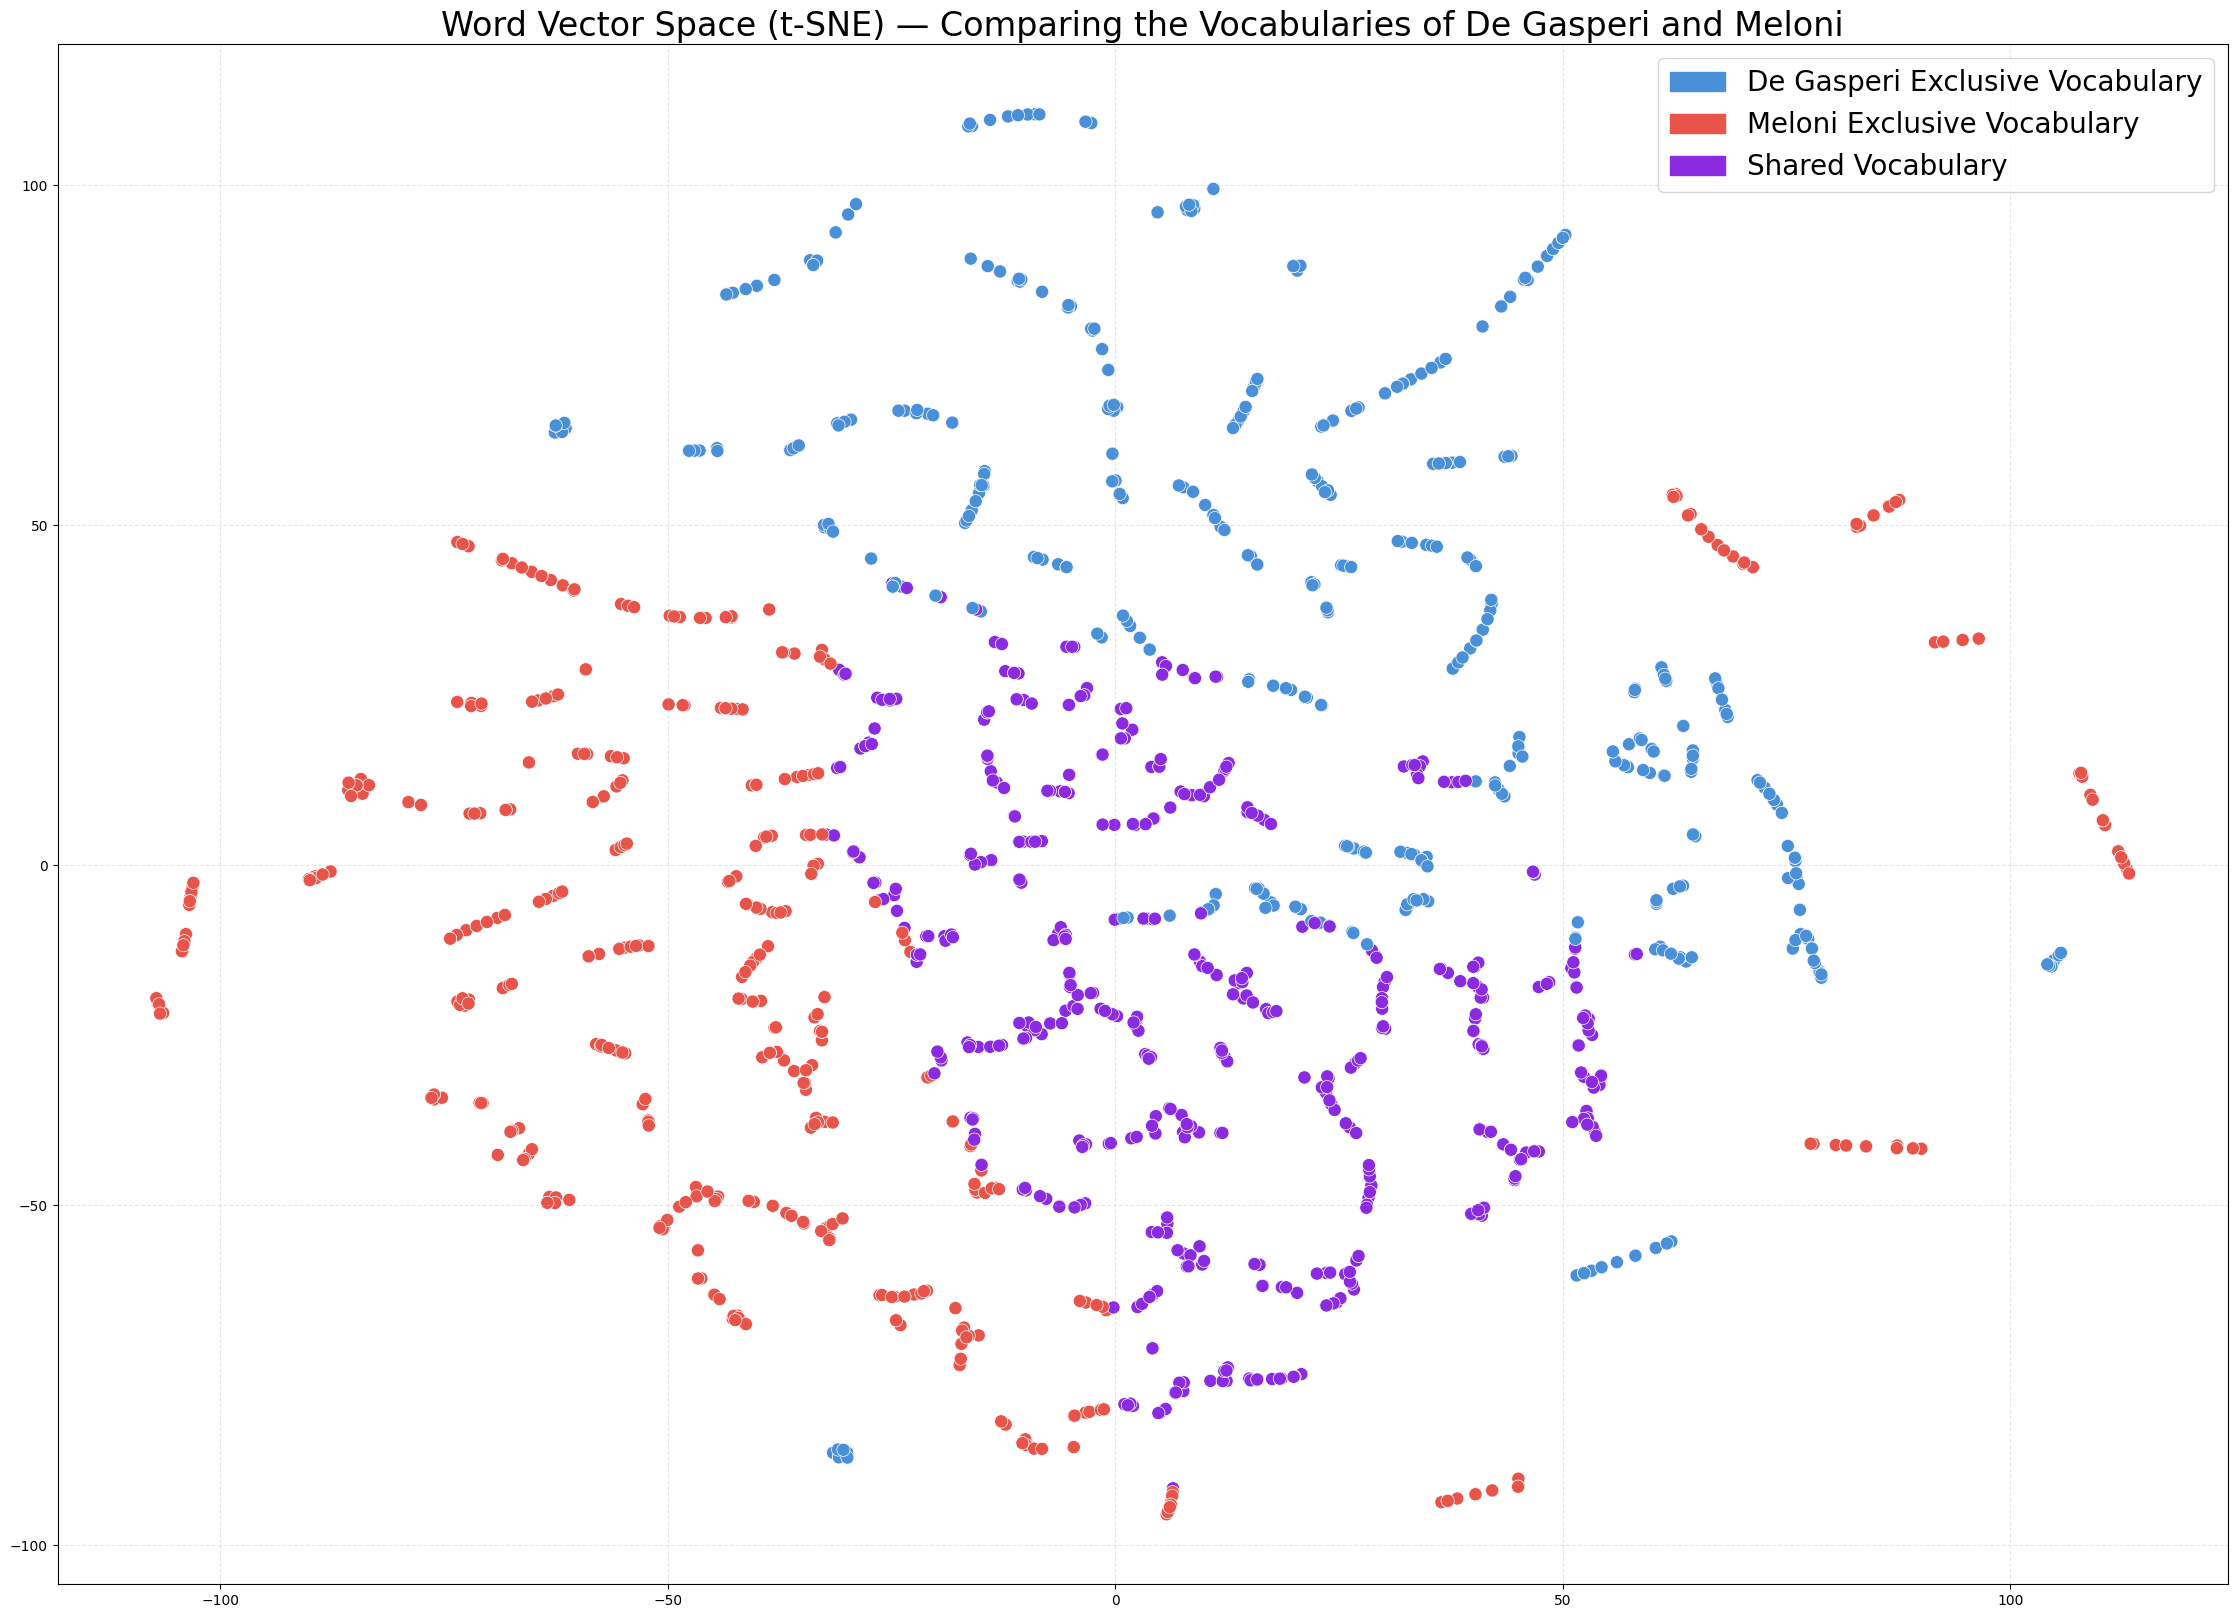

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

# --- CONFIGURATION CONSTANTS ---
MAX_LABELS = 80  # Total maximum number of data points that get a label
# -------------------------------

# 1. Define your corpus properly
degasperi_full_text = " ".join(degasperi_words)
meloni_full_text = " ".join(meloni_words)
corpus = [degasperi_full_text, meloni_full_text]

# 2. Get the unique set of your top 1000 words from both speakers
combined_top_words = list(top1000_degasperi.union(top1000_meloni))

# 3. Vectorize ONLY your top words
vectorizer = TfidfVectorizer(vocabulary=combined_top_words)
X = vectorizer.fit_transform(corpus)
word_vectors = X.T.toarray()

# 4. Reduce dimensions to 2D using t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='random')
word_coords = tsne.fit_transform(word_vectors)

# 5. Determine colors for ALL dots based on ownership
dot_colors = []
for word in combined_top_words:
    if word in top1000_degasperi and word in top1000_meloni:
        dot_colors.append('#8A2BE2')  # Purple (Shared)
    elif word in top1000_degasperi:
        dot_colors.append('#4A90D9')  # Blue (De Gasperi)
    else:
        dot_colors.append('#E8534A')  # Red (Meloni)

# 6. Define which words get labeled using MAX_LABELS
half_max = MAX_LABELS // 2
words_to_label = list(top1000_degasperi)[:half_max] + list(top1000_meloni)[:half_max]

# 7. Plot the graphical view
plt.figure(figsize=(28, 20))

# Plot all dots with their respective ownership colors
plt.scatter(
    word_coords[:, 0], word_coords[:, 1],
    alpha=1,
    c=dot_colors,
    edgecolors='w',
    linewidth=0.5,
    s=90  # dot size
)

# Annotate the subset of words
for i, word in enumerate(combined_top_words):
    if word in words_to_label:
        label_color = dot_colors[i]
        # plt.annotate(
        #     word,
        #     (word_coords[i, 0], word_coords[i, 1]),
        #     xytext=(5, 2),
        #     textcoords='offset points',
        #     fontsize=8,
        #     color='black',
        #     weight='normal'
        # )

# Legend via proxy artists
legend_handles = [
    mpatches.Patch(color='#4A90D9', label='De Gasperi Exclusive Vocabulary'),
    mpatches.Patch(color='#E8534A', label='Meloni Exclusive Vocabulary'),
    mpatches.Patch(color='#8A2BE2', label='Shared Vocabulary'),
]
plt.legend(handles=legend_handles, fontsize=20, loc='best')
plt.title("Word Vector Space (t-SNE) — Comparing the Vocabularies of De Gasperi and Meloni", fontsize=24)
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig("tsne_melonidegasperi.png", dpi=300)
plt.show()


## Sentiment Analysis

Oss: BERT cannot handle more than 512 tokens in one go
Oss: he raw probability scores and report distributions (e.g. median positive score per PM, per year) rather than hard positive/negative counts

### nlptown/bert-base-multilingual-uncased-sentiment

In [12]:
from transformers import pipeline



def sentiment(df):
    # 1. Initialize the new multilingual sentiment pipeline
    sentiment_classifier = pipeline(
        "text-classification",
        model="nlptown/bert-base-multilingual-uncased-sentiment",
        device=0  # GPU
    )

    # --- Assuming your DataFrame is loaded as 'df' ---
    # Example: df = pd.read_csv("political_transcripts.csv")
    df = df.dropna(subset=['text']).copy()
    texts = df['text'].tolist()

    # 2. Run the predictions with batching and truncation
    batch_size = 16 

    print("Running sentiment analysis...")
    sentiment_results = sentiment_classifier(
        texts, 
        batch_size=batch_size, 
        truncation=True, 
        max_length=512
    )

    df['sentiment_label'] = [res['label'] for res in sentiment_results]
    df['sentiment_score'] = [res['score'] for res in sentiment_results]

    # Calculate the aggregated score for each result in the list
    df['sentiment_aggregated'] = [
        (int(res['label'].split()[0]) * res['score']) / 5 
        for res in sentiment_results
    ]
    return df

meloni_df = sentiment(meloni_df)
degasperi_df = sentiment(degasperi_df)

meloni_df.to_csv(f"{BASE_DIR}/datasets/meloni/meloni_processed.csv")
degasperi_df.to_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_processed.csv")
degasperi_df.head()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running sentiment analysis...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Running sentiment analysis...


,politician,historical_date,location,keywords,text,token_count,mtld,sentiment_label,sentiment_score,sentiment_aggregated
0,degasperi,1906-02-13,Trento,"['conseguenze del suffragio universale', 'part...",[...] La modalità del suffragio universale Qua...,1313,145.027312,2 stars,0.370492,0.148197
1,degasperi,1902-01-2,Trento,"['questione universitaria', 'università italia...",[...] Incaricato dalla Presidenza dell’Associa...,3449,159.972801,2 stars,0.289392,0.115757
2,degasperi,1906-05-15,Trento,"['suffragio universale', 'popoli', 'deputati',...",Introduzione Necessità di far politica Chi par...,2258,135.551367,2 stars,0.405345,0.162138
3,degasperi,1906-09-10,Trento,"['applausi prolungati', 'studente carbonari', ...",[...] Parla il dott. Degasperi Entrando staman...,491,168.422781,5 stars,0.227740,0.227740
4,degasperi,1906-12-10,Trento,"['clericali', 'liberale', 'don rodrigo', 'clas...",La classificazione dei partiti riesce oltremod...,1064,128.144265,2 stars,0.411749,0.164699


In [13]:
# Calculate medians
degasperi_median = degasperi_df['sentiment_aggregated'].median()
meloni_median = meloni_df['sentiment_aggregated'].median()

print(f"De Gasperi Median Sentiment: {degasperi_median:.3f}")
print(f"Meloni Median Sentiment: {meloni_median:.3f}")

De Gasperi Median Sentiment: 0.265
Meloni Median Sentiment: 0.379


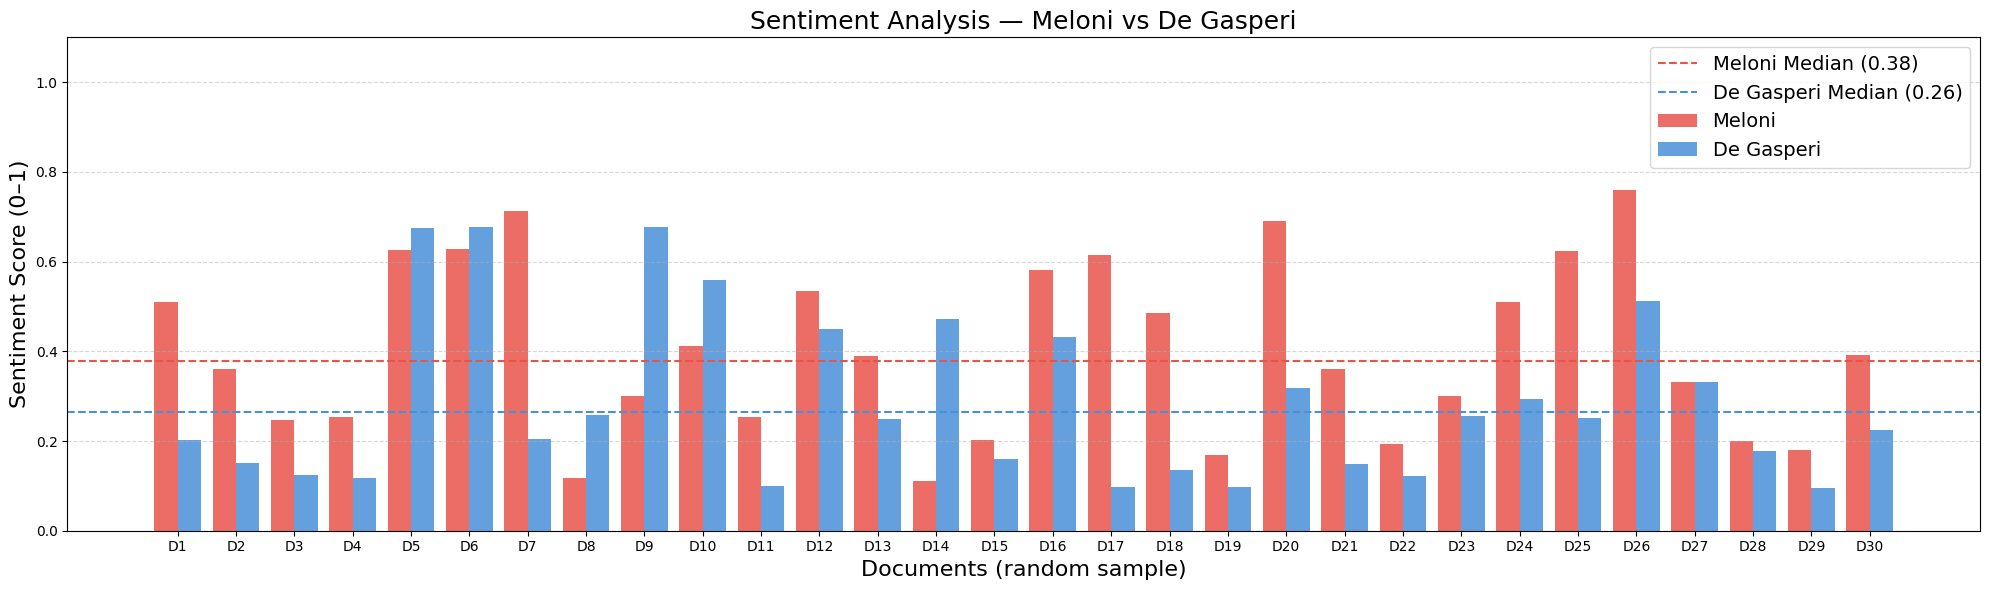

In [51]:
import matplotlib.pyplot as plt
import numpy as np

DOC_NUM = 30

meloni_plot = meloni_df["sentiment_aggregated"].sample(DOC_NUM, random_state=42).reset_index(drop=True)
degasperi_plot = degasperi_df["sentiment_aggregated"].sample(DOC_NUM, random_state=42).reset_index(drop=True)

meloni_med = meloni_df["sentiment_aggregated"].median()
degasperi_med = degasperi_df["sentiment_aggregated"].median()

x = np.arange(DOC_NUM)
width = 0.4

fig, ax = plt.subplots(figsize=(20, 6))

ax.bar(x - width/2, meloni_plot, width, label="Meloni", color="#E8534A", alpha=0.85)
ax.bar(x + width/2, degasperi_plot, width, label="De Gasperi", color="#4A90D9", alpha=0.85)

ax.axhline(meloni_med, color="#E8534A", linestyle="--", linewidth=1.5, label=f"Meloni Median ({meloni_med:.2f})")
ax.axhline(degasperi_med, color="#4A90D9", linestyle="--", linewidth=1.5, label=f"De Gasperi Median ({degasperi_med:.2f})")

ax.set_xlabel("Documents (random sample)", fontsize=16)
ax.set_ylabel("Sentiment Score (0–1)", fontsize=16)
ax.set_title("Sentiment Analysis — Meloni vs De Gasperi", fontsize=18)
ax.set_xticks(x)
ax.set_xticklabels([f"D{i+1}" for i in x], rotation=0, fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=14)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(f"sentiment_comparison_{DOC_NUM}.png", dpi=300)
plt.show()

In [15]:
import pandas as pd
meloni_df = pd.read_csv(f"{BASE_DIR}/datasets/meloni/meloni_processed.csv", index_col=0)
degasperi_df = pd.read_csv(f"{BASE_DIR}/datasets/degasperi/degasperi_processed.csv", index_col=0)

def print_scores(df):
    # Drop rows where sentiment_score is missing
    df["sentiment_score"] = pd.to_numeric(df["sentiment_score"], errors="coerce")

    mean_score  = df["sentiment_score"].mean()
    median_score = df["sentiment_score"].median()

    print(f"Mean sentiment score:   {mean_score:.4f}")
    print(f"Median sentiment score: {median_score:.4f}")

print("=== Meloni ===")
print_scores(meloni_df)
print("== De Gasperi ===")
print_scores(degasperi_df)

=== Meloni ===
Mean sentiment score:   0.4636
Median sentiment score: 0.4692
== De Gasperi ===
Mean sentiment score:   0.4068
Median sentiment score: 0.3627
